# Exploratory Data Analysis (EDA)
## Multi-Disease Prediction System

**Datasets:**
- Heart Disease (UCI Cleveland)
- Diabetes (Pima Indians)
- Breast Cancer (Wisconsin)

**Goal:** Understand each dataset before building any ML model.
We look for missing values, class imbalance, feature distributions, and correlations.

In [1]:
# ── Imports ────────────────────────────────────────────────
import sys
import os
sys.path.append('..')  # so we can import from the root folder

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Import our data loader
from src.data_loader import load_all_datasets

# Make all charts look clean and professional
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

print('All imports successful!')

All imports successful!


In [2]:
# ── Load all datasets ──────────────────────────────────────
datasets = load_all_datasets()

heart_df    = datasets['heart']
diabetes_df = datasets['diabetes']
cancer_df   = datasets['cancer']

print('Datasets loaded into variables: heart_df, diabetes_df, cancer_df')

  LOADING ALL DATASETS

Loading Heart Disease dataset...
  Heart Disease dataset saved → C:\Users\jain computer\OneDrive\Desktop\disease_prediction\data\raw\heart.csv
  Shape: 303 rows, 14 columns

Loading Diabetes dataset...
  Diabetes dataset saved → C:\Users\jain computer\OneDrive\Desktop\disease_prediction\data\raw\diabetes.csv
  Shape: 768 rows, 9 columns

Loading Breast Cancer dataset...
  Breast Cancer dataset saved → C:\Users\jain computer\OneDrive\Desktop\disease_prediction\data\raw\breast_cancer.csv
  Shape: 569 rows, 31 columns

  ALL DATASETS LOADED SUCCESSFULLY!
Datasets loaded into variables: heart_df, diabetes_df, cancer_df


---
# PART 1 — Heart Disease Dataset

In [3]:
# ── Basic info ─────────────────────────────────────────────
print('Shape:', heart_df.shape)
print('\nFirst 5 rows:')
heart_df.head()

Shape: (303, 14)

First 5 rows:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [4]:
# ── Data types and missing values ──────────────────────────
print('Data types and non-null counts:')
print(heart_df.info())
print('\nMissing values per column:')
print(heart_df.isnull().sum())

Data types and non-null counts:
<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB
None

Missing values per column:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca         

In [5]:
# ── Statistical summary ────────────────────────────────────
# This shows min, max, mean, std for every column
# Very useful for spotting outliers and understanding scale
heart_df.describe().round(2)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,299.00,301.00,303.00
mean,54.44,0.68,3.16,131.69,246.69,0.15,0.99,149.61,0.33,1.04,1.60,0.67,4.73,0.46
std,9.04,0.47,0.96,17.60,51.78,0.36,0.99,22.88,0.47,1.16,0.62,0.94,1.94,0.50
min,29.00,0.00,1.00,94.00,126.00,0.00,0.00,71.00,0.00,0.00,1.00,0.00,3.00,0.00
25%,48.00,0.00,3.00,120.00,211.00,0.00,0.00,133.50,0.00,0.00,1.00,0.00,3.00,0.00
50%,56.00,1.00,3.00,130.00,241.00,0.00,1.00,153.00,0.00,0.80,2.00,0.00,3.00,0.00
75%,61.00,1.00,4.00,140.00,275.00,0.00,2.00,166.00,1.00,1.60,2.00,1.00,7.00,1.00
max,77.00,1.00,4.00,200.00,564.00,1.00,2.00,202.00,1.00,6.20,3.00,3.00,7.00,1.00


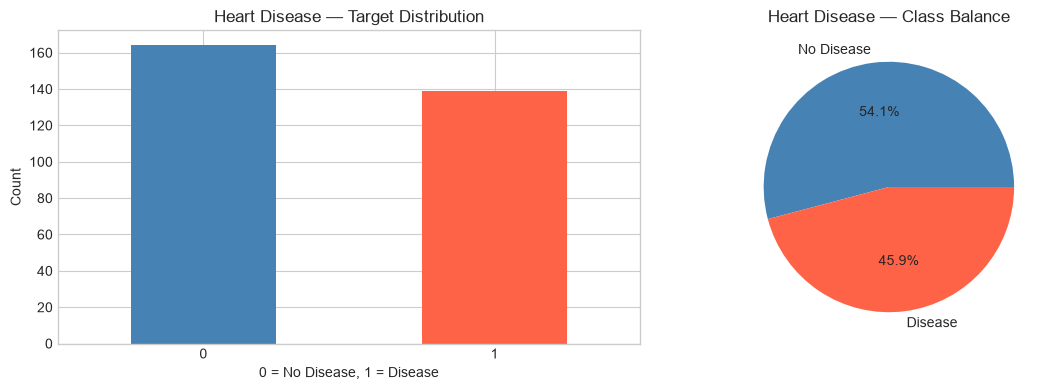

Target counts: {0: 164, 1: 139}


In [6]:
# ── Target distribution (class balance check) ──────────────
# IMPORTANT: If one class has far more samples than the other,
# the model will be biased. This is called class imbalance.

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
heart_df['target'].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue', 'tomato'])
axes[0].set_title('Heart Disease — Target Distribution')
axes[0].set_xlabel('0 = No Disease, 1 = Disease')
axes[0].set_ylabel('Count')
axes[0].tick_params(rotation=0)

# Pie chart
heart_df['target'].value_counts().plot(kind='pie', ax=axes[1],
    labels=['No Disease', 'Disease'], autopct='%1.1f%%',
    colors=['steelblue', 'tomato'])
axes[1].set_title('Heart Disease — Class Balance')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('../reports/heart_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Target counts:', heart_df['target'].value_counts().to_dict())

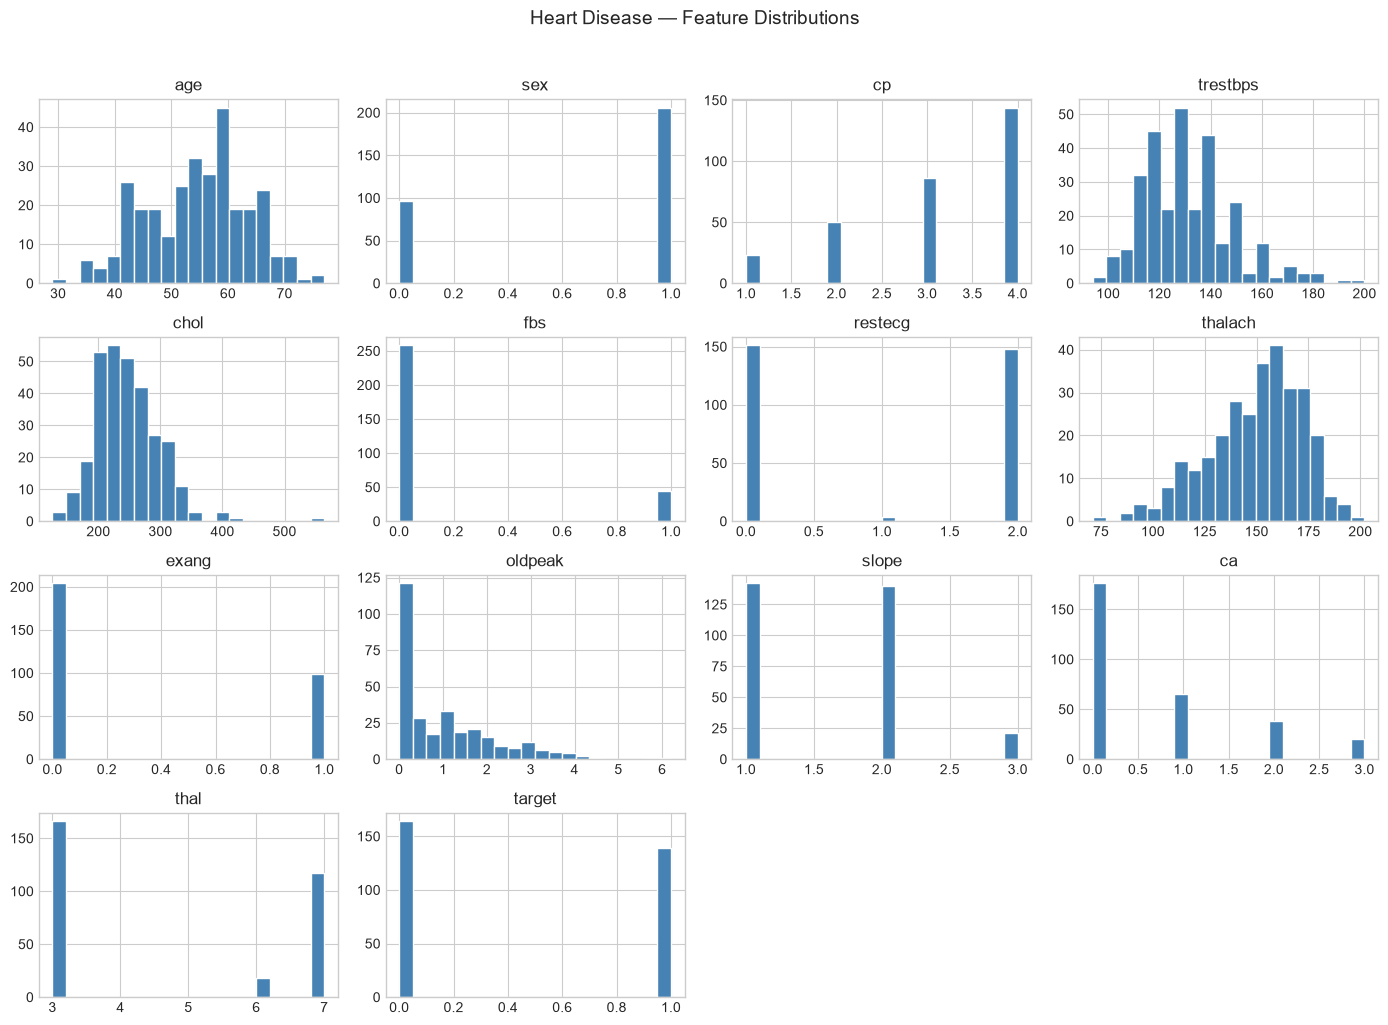

In [7]:
# ── Feature distributions ──────────────────────────────────
# Histograms for all numerical features
# This shows us the shape of each feature's data

heart_df.hist(figsize=(14, 10), bins=20, color='steelblue', edgecolor='white')
plt.suptitle('Heart Disease — Feature Distributions', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../reports/heart_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

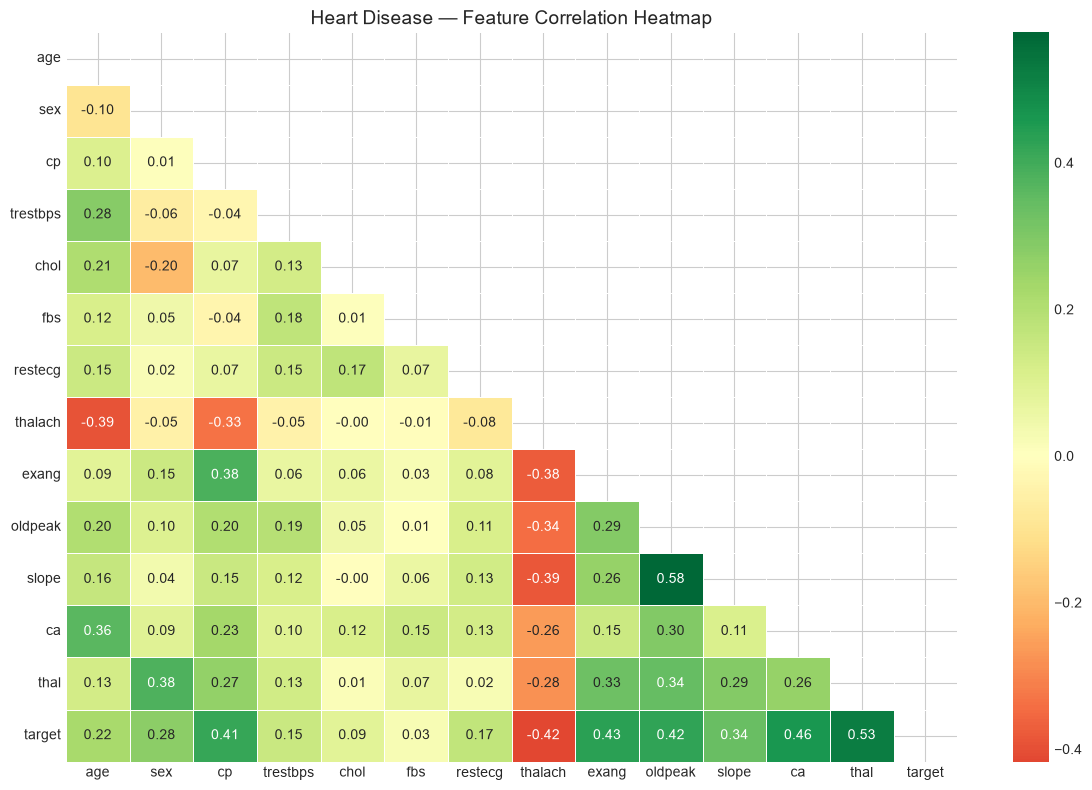

In [8]:
# ── Correlation heatmap ────────────────────────────────────
# Shows which features are correlated with each other
# And most importantly — which features are most correlated
# with the TARGET (last row/column)
# High correlation with target = important feature for prediction

plt.figure(figsize=(12, 8))
correlation = heart_df.corr()
mask = np.triu(np.ones_like(correlation, dtype=bool))  # hide upper triangle
sns.heatmap(correlation, annot=True, fmt='.2f', cmap='RdYlGn',
            mask=mask, center=0, linewidths=0.5)
plt.title('Heart Disease — Feature Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.savefig('../reports/heart_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

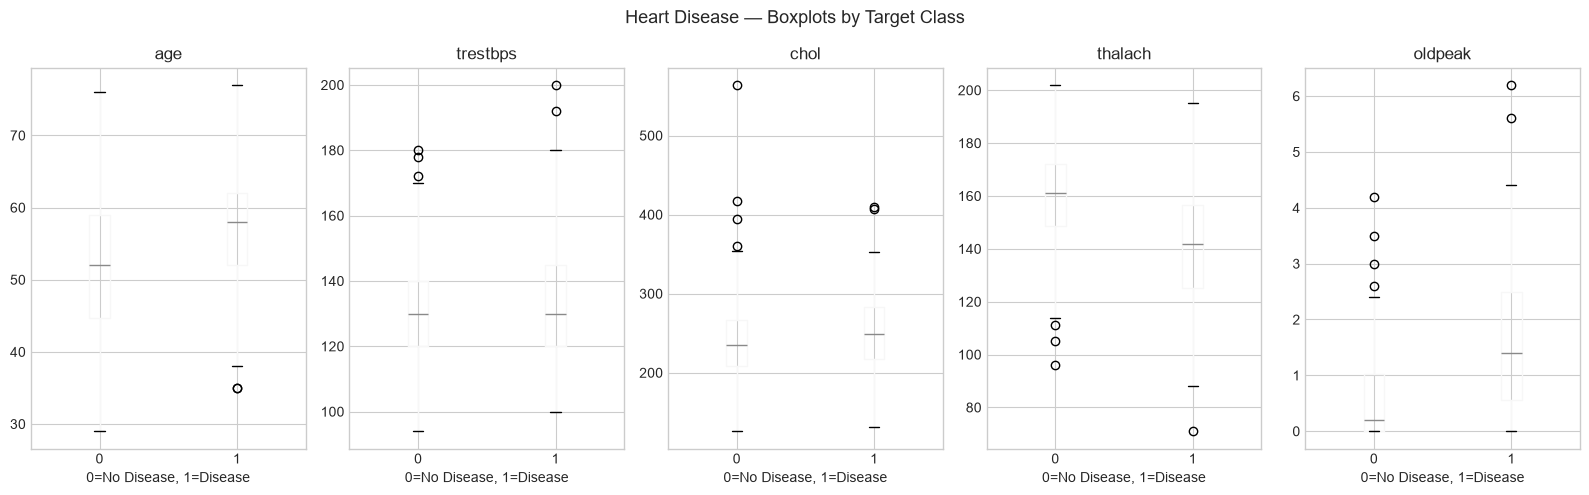

In [9]:
# ── Boxplots — spotting outliers ───────────────────────────
# Outliers are data points far away from the rest
# They appear as dots outside the box in a boxplot
# Outliers can confuse ML models

numerical_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

fig, axes = plt.subplots(1, len(numerical_cols), figsize=(16, 5))
for i, col in enumerate(numerical_cols):
    heart_df.boxplot(column=col, by='target', ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel('0=No Disease, 1=Disease')

plt.suptitle('Heart Disease — Boxplots by Target Class', fontsize=13)
plt.tight_layout()
plt.savefig('../reports/heart_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

---
# PART 2 — Diabetes Dataset

In [10]:
print('Shape:', diabetes_df.shape)
diabetes_df.head()

Shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [11]:
print('Missing values:')
print(diabetes_df.isnull().sum())
print('\nStatistical summary:')
diabetes_df.describe().round(2)

Missing values:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Statistical summary:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00
mean,3.85,120.89,69.11,20.54,79.80,31.99,0.47,33.24,0.35
std,3.37,31.97,19.36,15.95,115.24,7.88,0.33,11.76,0.48
min,0.00,0.00,0.00,0.00,0.00,0.00,0.08,21.00,0.00
25%,1.00,99.00,62.00,0.00,0.00,27.30,0.24,24.00,0.00
50%,3.00,117.00,72.00,23.00,30.50,32.00,0.37,29.00,0.00
75%,6.00,140.25,80.00,32.00,127.25,36.60,0.63,41.00,1.00
max,17.00,199.00,122.00,99.00,846.00,67.10,2.42,81.00,1.00


In [12]:
# ── Important check: Zero values that should not be zero ───
# In medical data, values like Glucose=0 or BloodPressure=0
# are biologically impossible — they are actually MISSING values
# disguised as zeros. We need to catch this!

zero_check_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
print('Zero counts in columns that cannot physically be zero:')
for col in zero_check_cols:
    zeros = (diabetes_df[col] == 0).sum()
    pct = zeros / len(diabetes_df) * 100
    print(f'  {col}: {zeros} zeros ({pct:.1f}%)')

Zero counts in columns that cannot physically be zero:
  Glucose: 5 zeros (0.7%)
  BloodPressure: 35 zeros (4.6%)
  SkinThickness: 227 zeros (29.6%)
  Insulin: 374 zeros (48.7%)
  BMI: 11 zeros (1.4%)


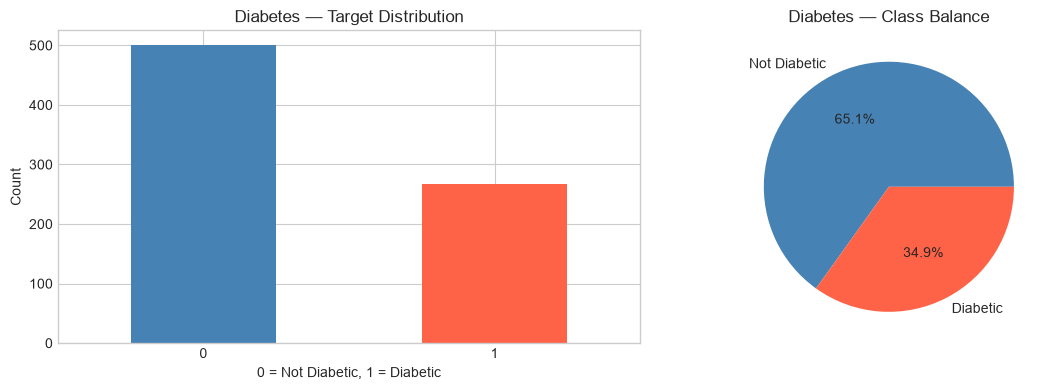

In [13]:
# ── Target distribution ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

diabetes_df['Outcome'].value_counts().plot(kind='bar', ax=axes[0],
    color=['steelblue', 'tomato'])
axes[0].set_title('Diabetes — Target Distribution')
axes[0].set_xlabel('0 = Not Diabetic, 1 = Diabetic')
axes[0].set_ylabel('Count')
axes[0].tick_params(rotation=0)

diabetes_df['Outcome'].value_counts().plot(kind='pie', ax=axes[1],
    labels=['Not Diabetic', 'Diabetic'], autopct='%1.1f%%',
    colors=['steelblue', 'tomato'])
axes[1].set_title('Diabetes — Class Balance')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('../reports/diabetes_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

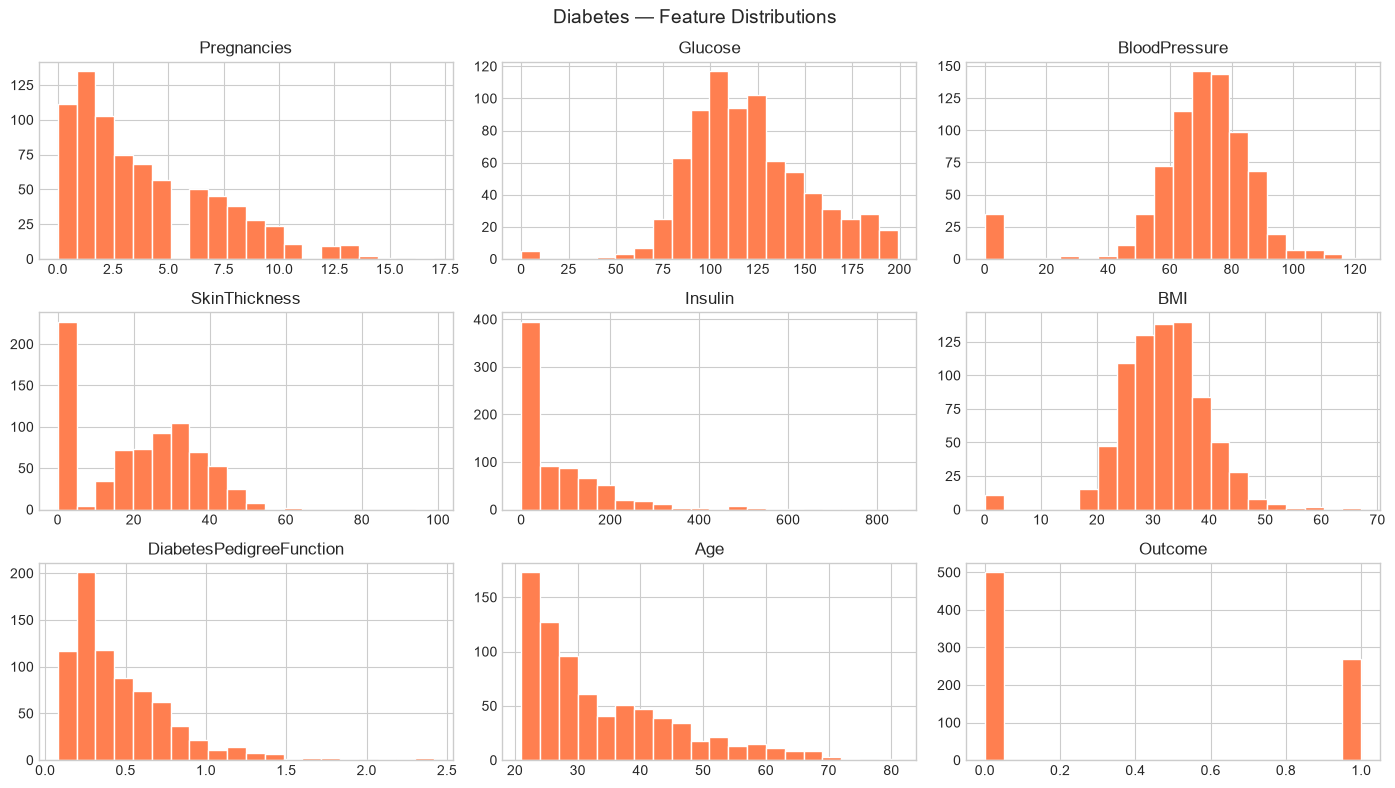

In [14]:
# ── Feature distributions ──────────────────────────────────
diabetes_df.hist(figsize=(14, 8), bins=20, color='coral', edgecolor='white')
plt.suptitle('Diabetes — Feature Distributions', fontsize=14)
plt.tight_layout()
plt.savefig('../reports/diabetes_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

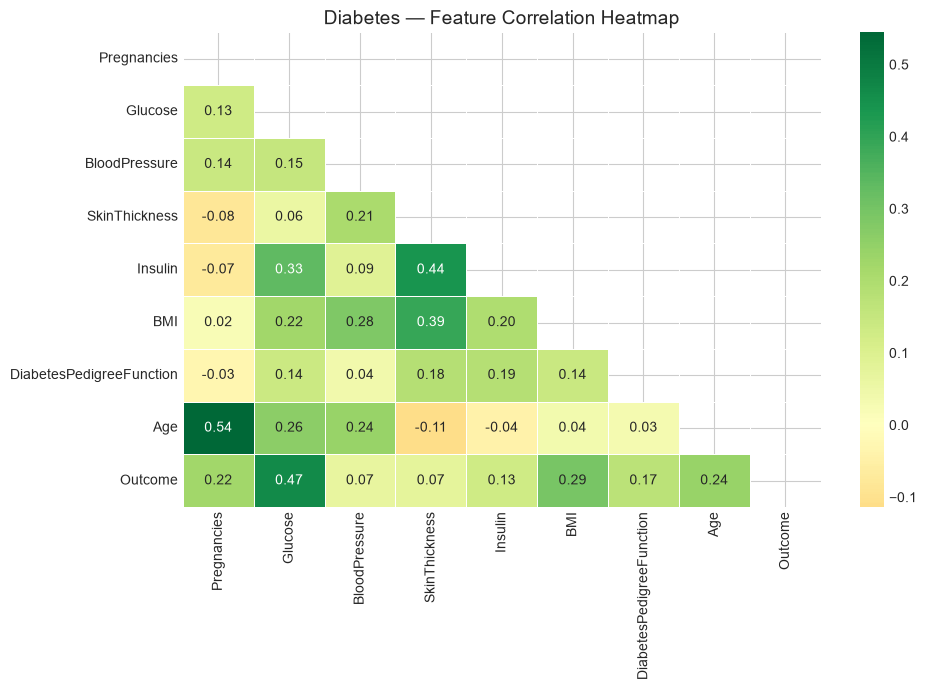

In [15]:
# ── Correlation heatmap ────────────────────────────────────
plt.figure(figsize=(10, 7))
correlation = diabetes_df.corr()
mask = np.triu(np.ones_like(correlation, dtype=bool))
sns.heatmap(correlation, annot=True, fmt='.2f', cmap='RdYlGn',
            mask=mask, center=0, linewidths=0.5)
plt.title('Diabetes — Feature Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.savefig('../reports/diabetes_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

---
# PART 3 — Breast Cancer Dataset

In [16]:
print('Shape:', cancer_df.shape)
cancer_df.head()

Shape: (569, 31)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,1
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,1
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,1
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,1
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,1


In [17]:
print('Missing values:')
print(cancer_df.isnull().sum().sum(), 'total missing values')
print('\nStatistical summary (first 5 features):')
cancer_df.iloc[:, :5].describe().round(2)

Missing values:
0 total missing values

Statistical summary (first 5 features):


,mean radius,mean texture,mean perimeter,mean area,mean smoothness
count,569.00,569.00,569.00,569.00,569.00
mean,14.13,19.29,91.97,654.89,0.10
std,3.52,4.30,24.30,351.91,0.01
min,6.98,9.71,43.79,143.50,0.05
25%,11.70,16.17,75.17,420.30,0.09
50%,13.37,18.84,86.24,551.10,0.10
75%,15.78,21.80,104.10,782.70,0.11
max,28.11,39.28,188.50,2501.00,0.16


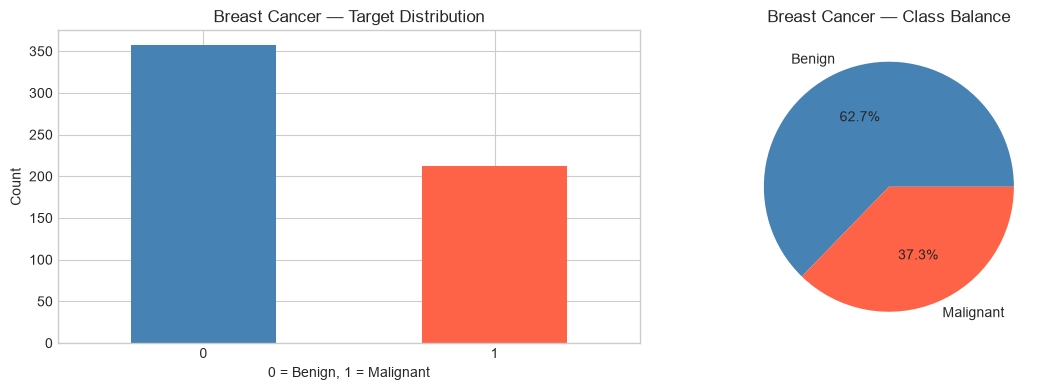

In [18]:
# ── Target distribution ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

cancer_df['target'].value_counts().plot(kind='bar', ax=axes[0],
    color=['steelblue', 'tomato'])
axes[0].set_title('Breast Cancer — Target Distribution')
axes[0].set_xlabel('0 = Benign, 1 = Malignant')
axes[0].set_ylabel('Count')
axes[0].tick_params(rotation=0)

cancer_df['target'].value_counts().plot(kind='pie', ax=axes[1],
    labels=['Benign', 'Malignant'], autopct='%1.1f%%',
    colors=['steelblue', 'tomato'])
axes[1].set_title('Breast Cancer — Class Balance')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('../reports/cancer_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

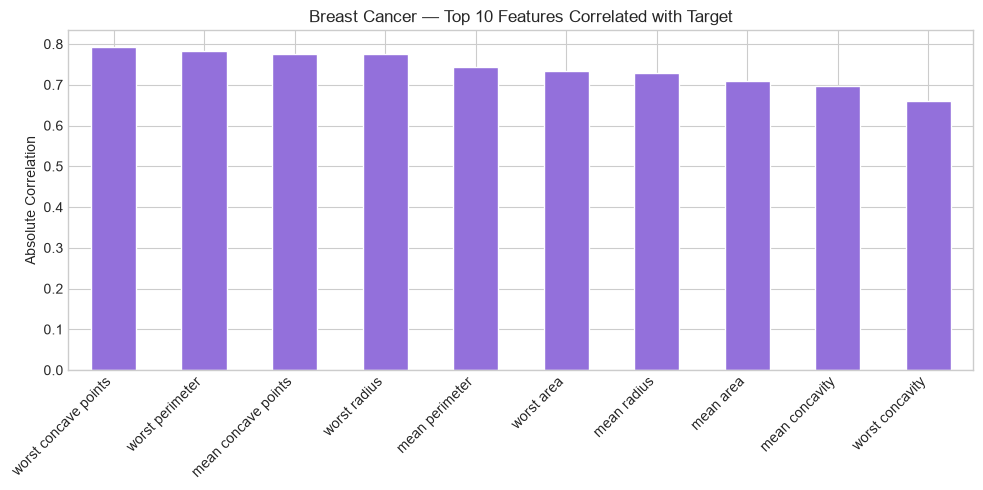

Top 10 features most correlated with cancer diagnosis:
worst concave points    0.793566
worst perimeter         0.782914
mean concave points     0.776614
worst radius            0.776454
mean perimeter          0.742636
worst area              0.733825
mean radius             0.730029
mean area               0.708984
mean concavity          0.696360
worst concavity         0.659610
Name: target, dtype: float64


In [19]:
# ── Top correlated features with target ────────────────────
# With 30 features we can't look at all — let's find
# the TOP 10 most correlated with the target

correlations = cancer_df.corr()['target'].drop('target').abs().sort_values(ascending=False)
top10 = correlations.head(10)

plt.figure(figsize=(10, 5))
top10.plot(kind='bar', color='mediumpurple', edgecolor='white')
plt.title('Breast Cancer — Top 10 Features Correlated with Target')
plt.ylabel('Absolute Correlation')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../reports/cancer_top_features.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 10 features most correlated with cancer diagnosis:')
print(top10)

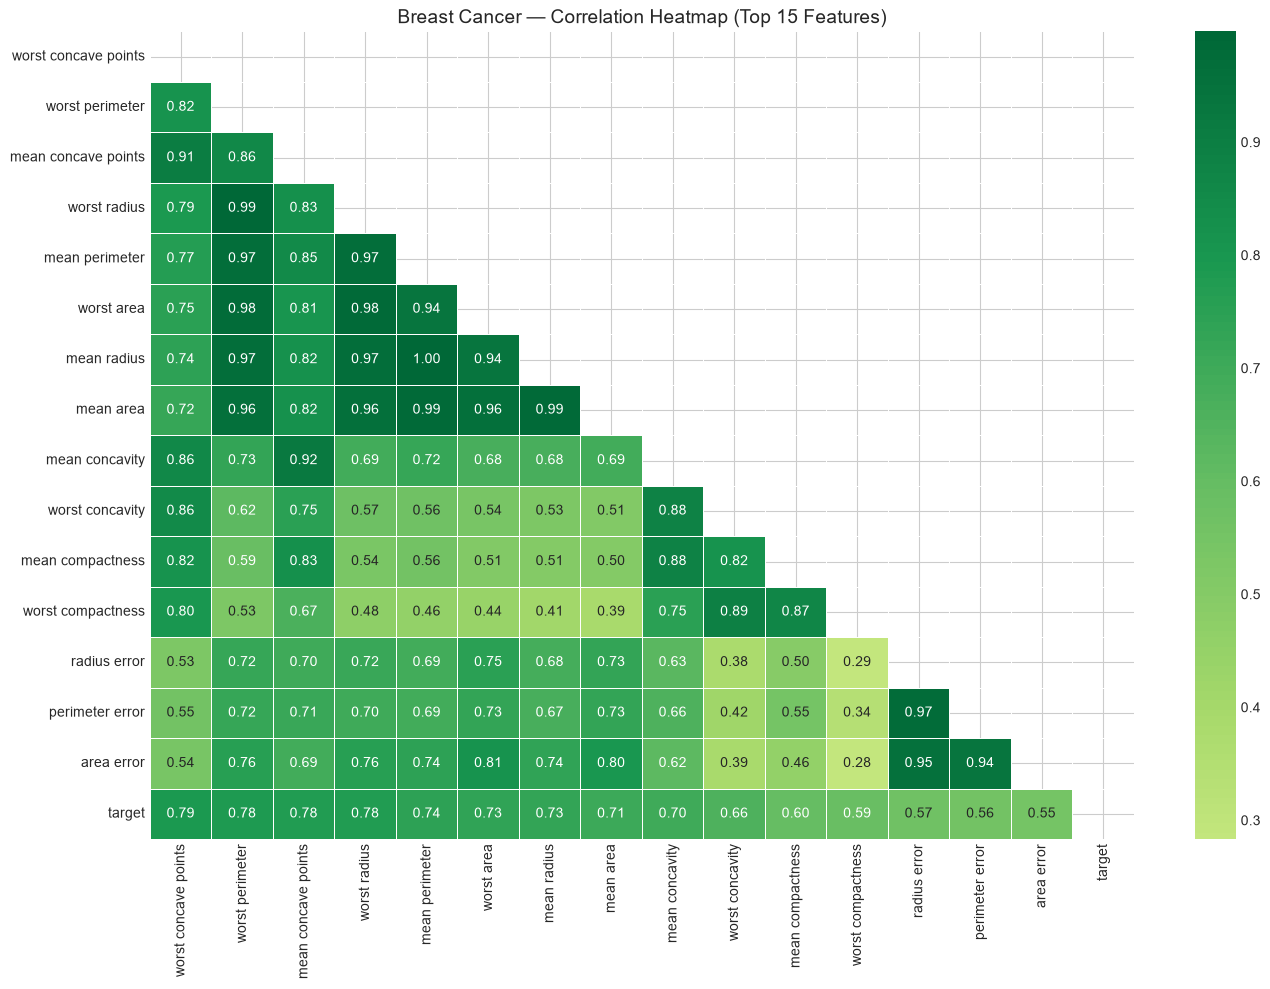

In [23]:
# ── Full correlation heatmap (top 15 features only) ────────
top15_features = correlations.head(15).index.tolist() + ['target']

plt.figure(figsize=(14, 10))
corr_subset = cancer_df[top15_features].corr()
mask = np.triu(np.ones_like(corr_subset, dtype=bool))
sns.heatmap(corr_subset, annot=True, fmt='.2f', cmap='RdYlGn',
            mask=mask, center=0, linewidths=0.5)
plt.title('Breast Cancer — Correlation Heatmap (Top 15 Features)', fontsize=14)
plt.tight_layout()
plt.savefig('../reports/cancer_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

---
# EDA Summary — Key Findings

## Heart Disease
- **303 samples**, 13 features
- Classes are roughly balanced (~54% disease, ~46% no disease)
- `thalach` (max heart rate), `cp` (chest pain), `ca` (vessels) are highly correlated with target
- A few missing values in `ca` and `thal` columns (marked as `?` in original)

## Diabetes
- **768 samples**, 8 features
- Mild class imbalance (~65% not diabetic, ~35% diabetic)
- **Important issue:** Glucose, BloodPressure, SkinThickness, Insulin, BMI have zeros that are biologically impossible → these are actually missing values!
- `Glucose` and `BMI` are most predictive features

## Breast Cancer
- **569 samples**, 30 features
- Mild class imbalance (~63% benign, ~37% malignant)
- Top predictive features: `concave points_worst`, `perimeter_worst`, `radius_worst`
- No missing values — cleanest of the three datasets

## What we'll do in preprocessing (Milestone 3):
1. Handle missing values in heart disease (`ca`, `thal`)
2. Replace impossible zeros in diabetes with median values
3. Scale all features using StandardScaler
4. Split into 80% train / 20% test